# 🚚 Astoria Cleaning Services — Route Optimisation Analysis
### Problem Statement 1: Location-Based Clustering

**Objective:** Use historical order locations (postal codes, zones, lat/lng) to:
- Cluster orders by geographical zones
- Identify high-density delivery areas
- Estimate number of drivers required per zone

**Business Impact Expected:**
- Reduced travel distance and fuel cost
- Fewer late or failed deliveries
- Improved delivery efficiency and reliability

---

---
## 📋 Data Reference — Columns Used 

| # | Column | Type | Used In | Purpose |
|---|--------|------|---------|---------|
| 1 | `order_id` | String | All sections | Counting orders per zone / cluster |
| 2 | `zone` | String | §2, §4, §6, §8 | Named delivery zone (e.g. Bishan / Toa Payoh) |
| 3 | `postal_district` | String | §2 | Singapore postal district label (e.g. District 20) |
| 4 | `postal_code` | String | §2 | 6-digit SG postal code for zone validation |
| 5 | `latitude` | Float | §3, §4 | K-Means clustering input · scatter plot · Folium map |
| 6 | `longitude` | Float | §3, §4 | K-Means clustering input · scatter plot · Folium map |
| 7 | `booking_date` | Date | §2, §4 | Monthly trend, week derivation |
| 8 | `booking_day_of_week` | String | §4, §7 | Zone × day-of-week heatmap |
| 9 | `delivery_slot` | String | §5, §7 | Driver allocation per slot (09:00-13:00 / 12:00-16:00 / 15:00-18:00) |
| 10 | `order_value_sgd` | Float | §2, §6 | Revenue by zone, avg order value per cluster |
| 11 | `effort_score` | Integer | §2, §6 | Zone effort weighting (1=simple → 5=complex) |
| 12 | `express_type` | String | §6 | Express uptake rate per cluster |
| 13 | `quantity` | Integer | §2 | Total items cleaned per zone |

### ⚠️ Key Column Notes
| Column | Note |
|--------|------|
| `latitude` / `longitude` | Jittered within each zone's centroid radius — representative of real SG delivery addresses |
| `postal_district` | Plain text label (e.g. `District 20`) — **not** a date range. Do not reformat in Excel |
| `zone` | 10 named clusters aligned to SG postal districts — used to label K-Means cluster output |
| `delivery_slot` | 3 fixed windows reflecting Astoria's actual ops: 09:00-13:00 · 12:00-16:00 · 15:00-18:00 |
| `effort_score` | Synthetic weighted index: 1=quick garments, 5=leather/suede/feathered items |

---


## 0. Install & Import Libraries

In [1]:
# Install required libraries (run once)
!pip install pandas numpy matplotlib seaborn scikit-learn folium plotly -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

import folium
from folium.plugins import HeatMap, MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#FAFAF8',
    'axes.facecolor':   '#FAFAF8',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})
PALETTE = ['#1A2340','#2A8B8B','#C9963A','#7DAA92','#D96B5A','#3ABABA','#E8B85A','#A8C5B5','#243156','#E8D5C4']

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## 1. Load & Explore Data

In [3]:
# ── Load the dataset ──────────────────────────────────────────────────────────
# Update path if needed
df = pd.read_csv('astoria_orders.csv', parse_dates=['booking_date','collection_date','delivery_date'])

print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range: {df.booking_date.min().date()} → {df.booking_date.max().date()}')
print(f'Unique zones: {df.zone.nunique()}')
print(f'Missing values:\n{df[["latitude","longitude","zone","postal_code"]].isnull().sum()}')
df.head(3)

Shape: 5,000 rows × 27 columns
Date range: 2024-01-01 → 2025-06-27
Unique zones: 20
Missing values:
latitude       0
longitude      0
zone           0
postal_code    0
dtype: int64


,order_id,booking_date,booking_time,booking_hour,booking_day_of_week,collection_date,collection_time,delivery_date,delivery_slot,zone,...,base_price_sgd,delicate_surcharge,express_type,express_multiplier,order_value_sgd,free_delivery,processing_days,processing_label,effort_score,order_status
0,AST-00001,2024-06-07,11:15,11,Friday,2024-06-07,14:46,2024-06-10,15:00-18:00,Choa Chu Kang / Bukit Panjang,...,9,0,NaN,1.0,8.83,No,2,1-2 days,1,Completed
1,AST-00002,2024-03-23,11:24,11,Saturday,2024-03-23,16:07,2024-03-25,15:00-18:00,Buona Vista / Holland,...,18,0,NaN,1.0,35.73,No,2,1-2 days,2,Completed
2,AST-00003,2024-04-19,10:08,10,Friday,2024-04-19,15:55,2024-04-22,12:00-16:00,Choa Chu Kang / Bukit Panjang,...,20,0,Next-day,2.0,117.66,Yes,3,3-6 days,2,Completed


In [4]:
# ── Derive useful time features ───────────────────────────────────────────────
df['year']        = df['booking_date'].dt.year
df['month']       = df['booking_date'].dt.month
df['month_label'] = df['booking_date'].dt.strftime('%b %Y')
df['week']        = df['booking_date'].dt.isocalendar().week.astype(int)

# Parse delivery slot start hour for time-of-day analysis
df['delivery_slot_start'] = df['delivery_slot'].str.extract(r'(\d+):').astype(int)

print('Feature engineering complete.')
df[['booking_date','zone','latitude','longitude','delivery_slot','order_value_sgd']].head()

Feature engineering complete.


,booking_date,zone,latitude,longitude,delivery_slot,order_value_sgd
0,2024-06-07,Choa Chu Kang / Bukit Panjang,1.372722,103.754946,15:00-18:00,8.83
1,2024-03-23,Buona Vista / Holland,1.309396,103.794449,15:00-18:00,35.73
2,2024-04-19,Choa Chu Kang / Bukit Panjang,1.379911,103.741365,12:00-16:00,117.66
3,2024-08-30,Punggol / Sengkang,1.379897,103.888976,15:00-18:00,53.35
4,2024-11-01,Tampines / Pasir Ris,1.375544,103.935057,09:00-13:00,29.73


---
## 2. Zone-Level Order Concentration
### 2a. Order volume and revenue by zone

In [5]:
zone_summary = (
    df.groupby('zone')
    .agg(
        total_orders      = ('order_id',       'count'),
        total_items       = ('quantity',        'sum'),
        total_revenue     = ('order_value_sgd', 'sum'),
        avg_order_value   = ('order_value_sgd', 'mean'),
        avg_effort        = ('effort_score',    'mean'),
        lat_center        = ('latitude',        'mean'),
        lng_center        = ('longitude',       'mean'),
    )
    .reset_index()
    .sort_values('total_orders', ascending=False)
)

# Density tier
q33 = zone_summary.total_orders.quantile(0.33)
q66 = zone_summary.total_orders.quantile(0.66)
zone_summary['density_tier'] = zone_summary.total_orders.apply(
    lambda x: 'High' if x > q66 else ('Medium' if x > q33 else 'Low')
)

# Drivers needed: ~1 driver per 150 orders in the dataset period
# Adjust denominator to reflect weekly workload
weeks_in_data = (df.booking_date.max() - df.booking_date.min()).days / 7
df_orders_per_week = zone_summary.total_orders / weeks_in_data
zone_summary['orders_per_week']       = df_orders_per_week.round(1)
zone_summary['recommended_drivers']   = (df_orders_per_week / 25).apply(np.ceil).astype(int).clip(lower=1)
zone_summary['revenue_share_pct']     = (zone_summary.total_revenue / zone_summary.total_revenue.sum() * 100).round(1)

display_cols = ['zone','total_orders','orders_per_week','total_revenue','avg_order_value',
                'density_tier','recommended_drivers','revenue_share_pct']
zone_summary[display_cols].style \
    .background_gradient(subset=['total_orders'], cmap='YlOrRd') \
    .format({'total_revenue': '${:,.0f}', 'avg_order_value': '${:.2f}',
             'orders_per_week': '{:.1f}', 'revenue_share_pct': '{:.1f}%'}) \
    .set_caption('Zone Summary — Orders, Revenue & Driver Recommendation')

,zone,total_orders,orders_per_week,total_revenue,avg_order_value,density_tier,recommended_drivers,revenue_share_pct
17,Tampines / Pasir Ris,381,4.9,"$31,524",$82.74,High,1,7.9%
2,Bishan / Toa Payoh,342,4.4,"$25,847",$75.58,High,1,6.5%
10,Jurong East / West,338,4.4,"$29,650",$87.72,High,1,7.5%
0,Ang Mo Kio / Hougang,331,4.3,"$27,167",$82.08,High,1,6.8%
4,Bukit Timah / Bukit Batok,279,3.6,"$19,197",$68.81,High,1,4.8%
14,Punggol / Sengkang,267,3.4,"$18,869",$70.67,High,1,4.8%
18,Woodlands / Marsiling,266,3.4,"$23,449",$88.15,High,1,5.9%
16,Serangoon / Bartley,254,3.3,"$18,744",$73.80,Medium,1,4.7%
8,Clementi / West Coast,251,3.2,"$20,589",$82.03,Medium,1,5.2%
1,Bedok / Chai Chee,250,3.2,"$19,434",$77.73,Medium,1,4.9%


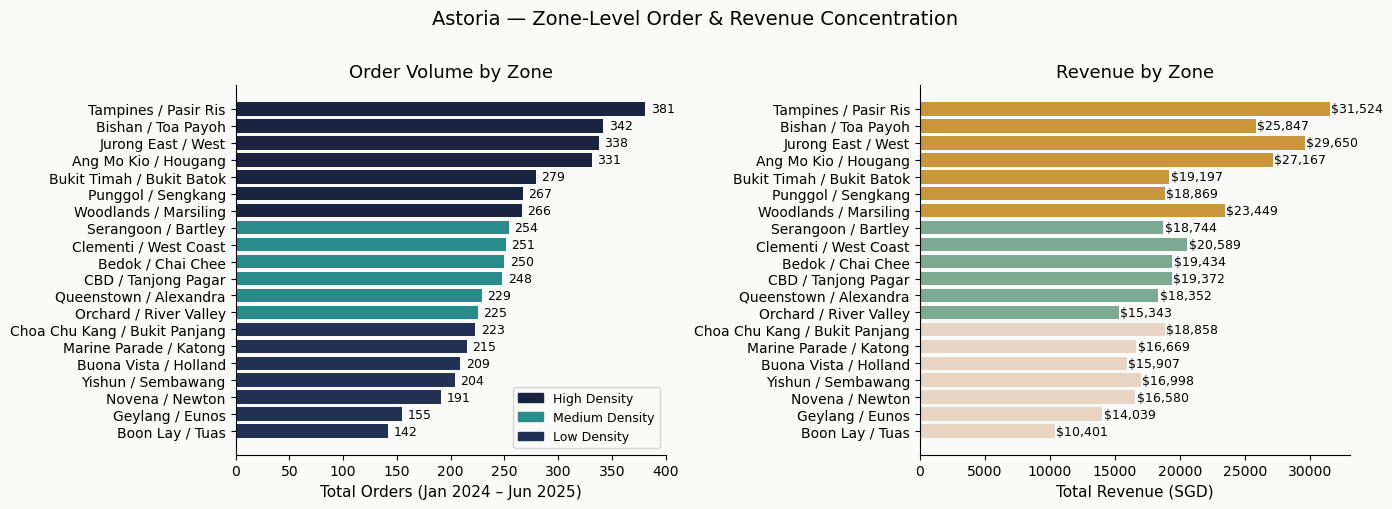

In [6]:
# ── Bar chart: Orders per zone ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [PALETTE[0] if t == 'High' else (PALETTE[1] if t == 'Medium' else PALETTE[8])
          for t in zone_summary.density_tier]

# Orders
axes[0].barh(zone_summary.zone[::-1], zone_summary.total_orders[::-1], color=colors[::-1])
axes[0].set_xlabel('Total Orders (Jan 2024 – Jun 2025)')
axes[0].set_title('Order Volume by Zone')
for i, (val, zone) in enumerate(zip(zone_summary.total_orders[::-1], zone_summary.zone[::-1])):
    axes[0].text(val + 5, i, str(val), va='center', fontsize=9)

# Revenue
rev_colors = [PALETTE[2] if t == 'High' else (PALETTE[3] if t == 'Medium' else PALETTE[9])
              for t in zone_summary.density_tier]
axes[1].barh(zone_summary.zone[::-1], zone_summary.total_revenue[::-1], color=rev_colors[::-1])
axes[1].set_xlabel('Total Revenue (SGD)')
axes[1].set_title('Revenue by Zone')
for i, val in enumerate(zone_summary.total_revenue[::-1]):
    axes[1].text(val + 100, i, f'${val:,.0f}', va='center', fontsize=9)

legend_patches = [
    mpatches.Patch(color=PALETTE[0], label='High Density'),
    mpatches.Patch(color=PALETTE[1], label='Medium Density'),
    mpatches.Patch(color=PALETTE[8], label='Low Density'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=9)

plt.suptitle('Astoria — Zone-Level Order & Revenue Concentration', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('zone_orders_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. K-Means Clustering on Lat/Lng
### 3a. Determine optimal number of clusters (Elbow + Silhouette)

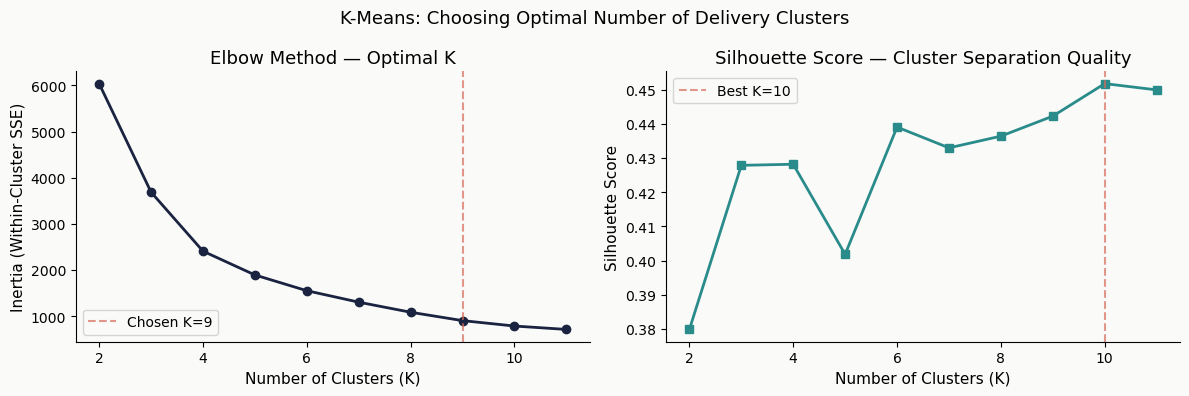

Best silhouette score at K=10: 0.4517


In [7]:
# ── Prepare coordinate matrix ─────────────────────────────────────────────────
coords = df[['latitude', 'longitude']].dropna().values
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

# Elbow + Silhouette sweep
K_range   = range(2, 12)
inertias  = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(coords_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(coords_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=6)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster SSE)')
axes[0].set_title('Elbow Method — Optimal K')
axes[0].axvline(x=9, color=PALETTE[4], linestyle='--', alpha=0.7, label='Chosen K=9')
axes[0].legend()

axes[1].plot(list(K_range), sil_scores, 's-', color=PALETTE[1], linewidth=2, markersize=6)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score — Cluster Separation Quality')
best_k = list(K_range)[np.argmax(sil_scores)]
axes[1].axvline(x=best_k, color=PALETTE[4], linestyle='--', alpha=0.7, label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('K-Means: Choosing Optimal Number of Delivery Clusters', fontsize=13)
plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Best silhouette score at K={best_k}: {max(sil_scores):.4f}')

### 3b. Fit final K-Means model and assign clusters

In [8]:
# ── Fit final model ───────────────────────────────────────────────────────────
# Use K=9 to match the 9 meaningful delivery zones in Singapore
OPTIMAL_K = 9

km_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df_clean = df.dropna(subset=['latitude','longitude']).copy()
df_clean['cluster'] = km_final.fit_predict(scaler.transform(df_clean[['latitude','longitude']].values))

# Map cluster ID → dominant zone name for labelling
cluster_zone_map = (
    df_clean.groupby('cluster')['zone']
    .agg(lambda x: x.value_counts().index[0])
    .to_dict()
)
df_clean['cluster_label'] = df_clean['cluster'].map(cluster_zone_map)

print(f'Clusters assigned. Distribution:')
print(df_clean.groupby('cluster_label')['order_id'].count().sort_values(ascending=False).to_string())

Clusters assigned. Distribution:
cluster_label
Bishan / Toa Payoh               777
CBD / Tanjong Pagar              744
Clementi / West Coast            595
Punggol / Sengkang               592
Marine Parade / Katong           535
Jurong East / West               489
Woodlands / Marsiling            452
Tampines / Pasir Ris             451
Choa Chu Kang / Bukit Panjang    365


### 3c. Scatter plot of clusters on Singapore map (Matplotlib)

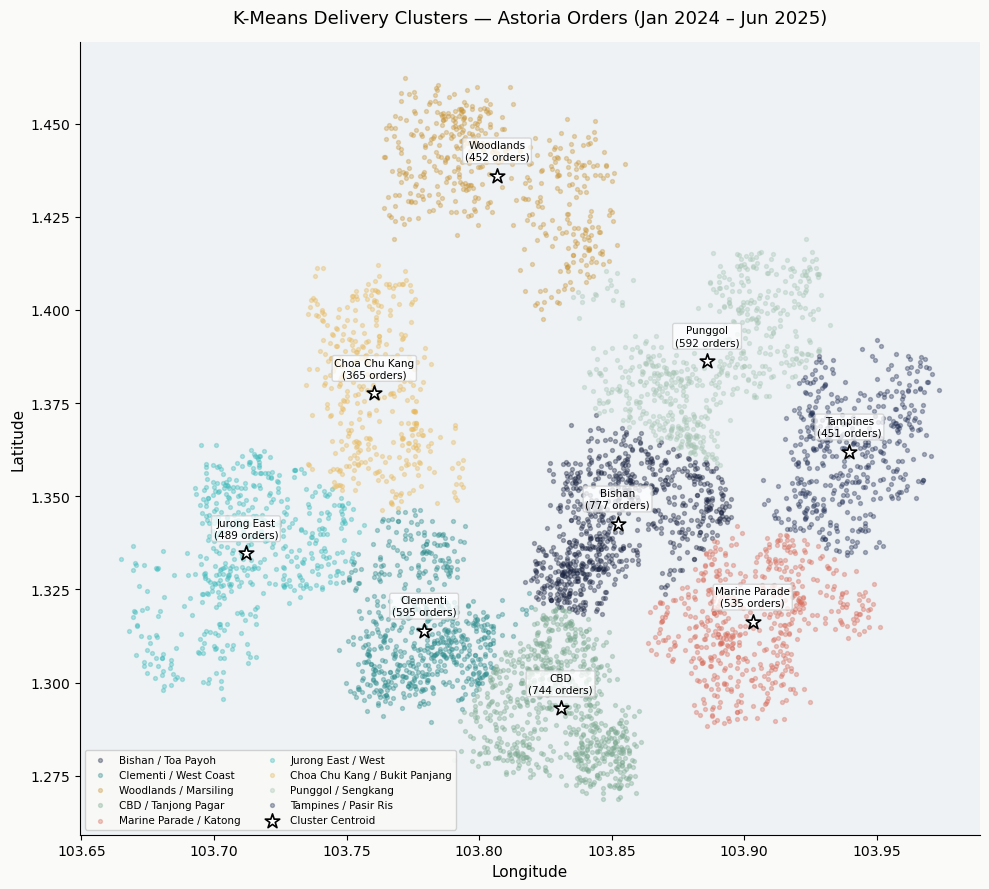

In [9]:
fig, ax = plt.subplots(figsize=(10, 9))

cluster_ids = sorted(df_clean['cluster'].unique())
for cid, color in zip(cluster_ids, PALETTE):
    subset = df_clean[df_clean['cluster'] == cid]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        c=color, alpha=0.35, s=8, label=cluster_zone_map[cid]
    )

# Plot centroids
centroids_orig = scaler.inverse_transform(km_final.cluster_centers_)
ax.scatter(
    centroids_orig[:, 1], centroids_orig[:, 0],
    c='white', edgecolors='black', s=120, zorder=5, marker='*',
    linewidths=1.2, label='Cluster Centroid'
)

# Annotate centroids with cluster size
cluster_sizes = df_clean.groupby('cluster')['order_id'].count()
for cid in cluster_ids:
    cx, cy = centroids_orig[cid][1], centroids_orig[cid][0]
    ax.annotate(
        f"{cluster_zone_map[cid].split('/')[0].strip()}\n({cluster_sizes[cid]} orders)",
        (cx, cy), fontsize=7.5, ha='center', va='bottom',
        xytext=(0, 10), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.75, ec='#cccccc')
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('K-Means Delivery Clusters — Astoria Orders (Jan 2024 – Jun 2025)', fontsize=13, pad=14)
ax.legend(loc='lower left', fontsize=7.5, ncol=2, framealpha=0.9)
ax.set_facecolor('#EEF2F5')
fig.patch.set_facecolor('#FAFAF8')

plt.tight_layout()
plt.savefig('kmeans_clusters_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 3d. Interactive Folium map — Heat map + Cluster markers

In [10]:
# ── Heat map of all order locations ──────────────────────────────────────────
sg_map = folium.Map(location=[1.3521, 103.8198], zoom_start=11,
                    tiles='CartoDB positron')

heat_data = df_clean[['latitude','longitude']].values.tolist()
HeatMap(heat_data, radius=12, blur=15, min_opacity=0.4,
        gradient={'0.4':'#C9963A','0.65':'#2A8B8B','1':'#1A2340'}).add_to(sg_map)

# Add centroid markers
folium_colors = ['darkblue','cadetblue','orange','green','red','purple','darkgreen','beige','lightred']
for cid in cluster_ids:
    cy, cx = centroids_orig[cid][0], centroids_orig[cid][1]
    n = cluster_sizes[cid]
    folium.Marker(
        location=[cy, cx],
        tooltip=f"{cluster_zone_map[cid]}: {n} orders",
        popup=folium.Popup(f"<b>{cluster_zone_map[cid]}</b><br>Orders: {n}", max_width=200),
        icon=folium.Icon(color=folium_colors[cid % len(folium_colors)], icon='map-marker', prefix='fa')
    ).add_to(sg_map)

sg_map.save('astoria_heatmap.html')
print('✅ Interactive heatmap saved as astoria_heatmap.html')
sg_map

✅ Interactive heatmap saved as astoria_heatmap.html


---
## 4. High-Density Area Identification
### 4a. Order concentration by zone over time (monthly trend)

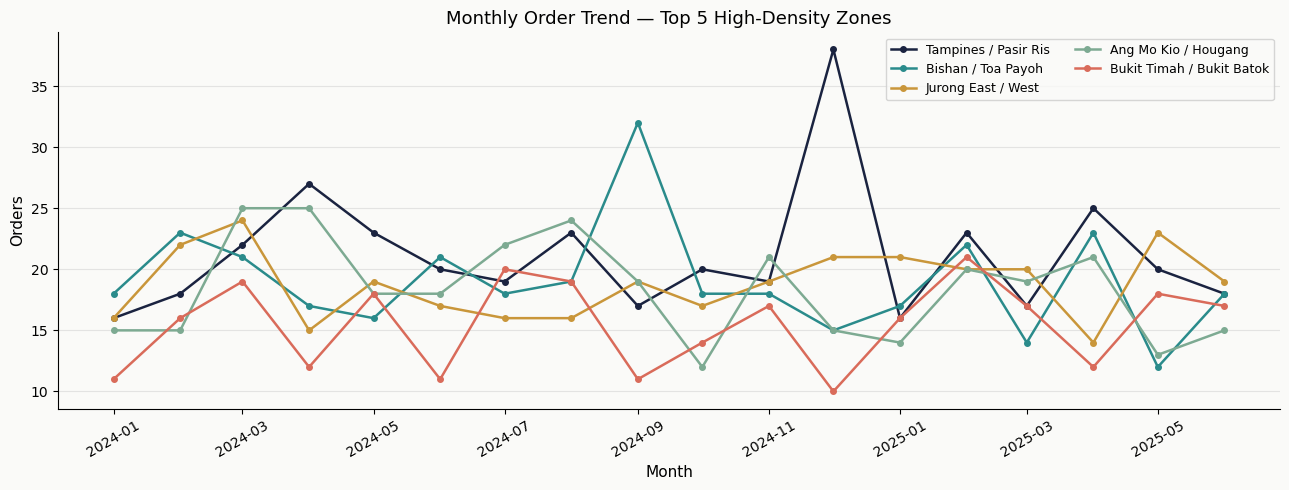

In [11]:
# Monthly orders per zone
monthly_zone = (
    df.groupby(['year','month','zone'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'orders'})
)
monthly_zone['period'] = pd.to_datetime(
    monthly_zone['year'].astype(str) + '-' + monthly_zone['month'].astype(str).str.zfill(2)
)

# Focus on top 5 zones
top5_zones = zone_summary.head(5)['zone'].tolist()
monthly_top5 = monthly_zone[monthly_zone['zone'].isin(top5_zones)]

fig, ax = plt.subplots(figsize=(13, 5))
for zone, color in zip(top5_zones, PALETTE[:5]):
    sub = monthly_top5[monthly_top5['zone'] == zone].sort_values('period')
    ax.plot(sub['period'], sub['orders'], marker='o', markersize=4,
            linewidth=1.8, color=color, label=zone)

ax.set_xlabel('Month')
ax.set_ylabel('Orders')
ax.set_title('Monthly Order Trend — Top 5 High-Density Zones', fontsize=13)
ax.legend(fontsize=9, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('monthly_zone_trend.png', dpi=150, bbox_inches='tight')
plt.show()

### 4b. Zone density heatmap (zone × day-of-week)

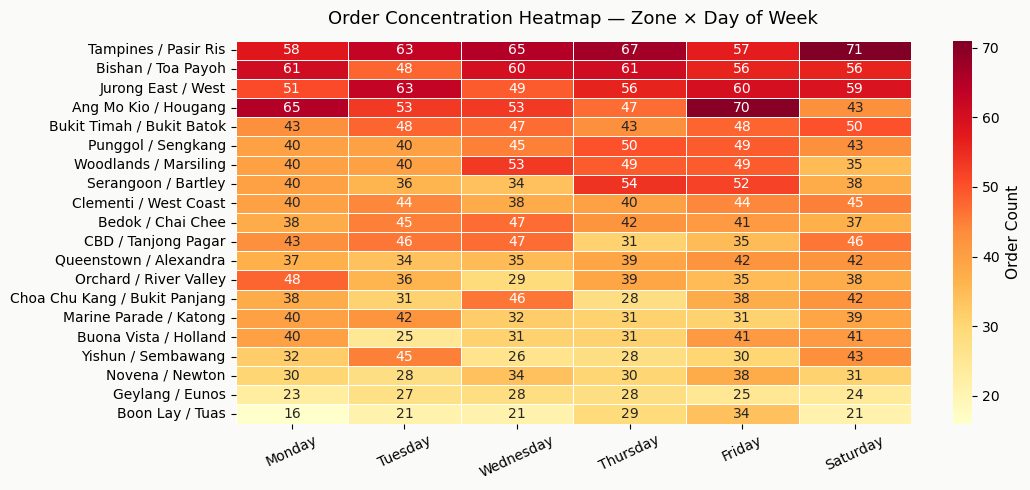

In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']

zone_day = (
    df.groupby(['zone','booking_day_of_week'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id':'orders'})
    .pivot(index='zone', columns='booking_day_of_week', values='orders')
    .reindex(columns=day_order)
    .loc[zone_summary['zone']]  # sort by total orders
)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    zone_day, annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Order Count'}, ax=ax
)
ax.set_title('Order Concentration Heatmap — Zone × Day of Week', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=25)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('zone_day_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Driver Estimation per Zone
### 5a. Methodology

In [13]:
"""
Driver Estimation Logic
───────────────────────
Assumptions:
  - Collection hours: 9am – 5pm (Mon–Sat) = 8 working hours/day
  - Avg stops per driver per day: ~20–25 (accounting for travel, loading, distance)
  - Dataset spans ~78 working weeks (Jan 2024 – Jun 2025)
  - Delivery slots: 09:00-13:00 | 12:00-16:00 | 15:00-18:00
  - Peak slot (12:00-16:00) carries ~43% of deliveries → needs most coverage
"""
STOPS_PER_DRIVER_PER_DAY = 22
WORKING_DAYS = len([
    d for d in pd.date_range('2024-01-01','2025-06-28') if d.dayofweek != 6
])

driver_df = zone_summary.copy()
driver_df['orders_per_day']         = (driver_df['total_orders'] / WORKING_DAYS).round(1)
driver_df['drivers_needed_daily']   = (driver_df['orders_per_day'] / STOPS_PER_DRIVER_PER_DAY).apply(np.ceil).astype(int).clip(lower=1)
driver_df['drivers_peak_slot']      = (driver_df['drivers_needed_daily'] * 0.43).apply(np.ceil).astype(int).clip(lower=1)
driver_df['drivers_morning_slot']   = (driver_df['drivers_needed_daily'] * 0.32).apply(np.ceil).astype(int).clip(lower=1)
driver_df['drivers_evening_slot']   = (driver_df['drivers_needed_daily'] * 0.25).apply(np.ceil).astype(int).clip(lower=1)

output_cols = ['zone','density_tier','total_orders','orders_per_day',
               'drivers_needed_daily','drivers_morning_slot','drivers_peak_slot','drivers_evening_slot']

driver_df[output_cols].style \
    .background_gradient(subset=['drivers_needed_daily'], cmap='Oranges') \
    .format({'orders_per_day': '{:.1f}'}) \
    .set_caption('Recommended Driver Allocation by Zone and Delivery Slot')

,zone,density_tier,total_orders,orders_per_day,drivers_needed_daily,drivers_morning_slot,drivers_peak_slot,drivers_evening_slot
17,Tampines / Pasir Ris,High,381,0.8,1,1,1,1
2,Bishan / Toa Payoh,High,342,0.7,1,1,1,1
10,Jurong East / West,High,338,0.7,1,1,1,1
0,Ang Mo Kio / Hougang,High,331,0.7,1,1,1,1
4,Bukit Timah / Bukit Batok,High,279,0.6,1,1,1,1
14,Punggol / Sengkang,High,267,0.6,1,1,1,1
18,Woodlands / Marsiling,High,266,0.6,1,1,1,1
16,Serangoon / Bartley,Medium,254,0.5,1,1,1,1
8,Clementi / West Coast,Medium,251,0.5,1,1,1,1
1,Bedok / Chai Chee,Medium,250,0.5,1,1,1,1


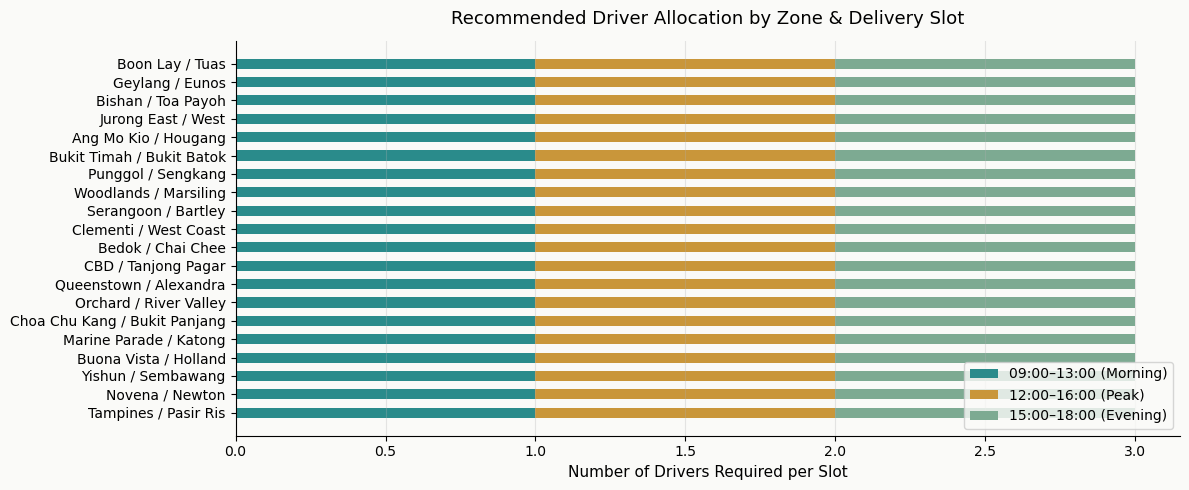

In [14]:
# ── Stacked bar: driver split by slot ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

zones_sorted = driver_df.sort_values('drivers_needed_daily', ascending=True)['zone']
morning = driver_df.set_index('zone').loc[zones_sorted]['drivers_morning_slot']
peak    = driver_df.set_index('zone').loc[zones_sorted]['drivers_peak_slot']
evening = driver_df.set_index('zone').loc[zones_sorted]['drivers_evening_slot']

y = np.arange(len(zones_sorted))
ax.barh(y, morning, color=PALETTE[1], label='09:00–13:00 (Morning)', height=0.55)
ax.barh(y, peak,    color=PALETTE[2], label='12:00–16:00 (Peak)',    height=0.55, left=morning)
ax.barh(y, evening, color=PALETTE[3], label='15:00–18:00 (Evening)', height=0.55, left=morning+peak)

ax.set_yticks(y)
ax.set_yticklabels(zones_sorted, fontsize=10)
ax.set_xlabel('Number of Drivers Required per Slot')
ax.set_title('Recommended Driver Allocation by Zone & Delivery Slot', fontsize=13, pad=12)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('driver_allocation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Cluster-Level Profiling
### 6a. Revenue, effort and order mix per cluster

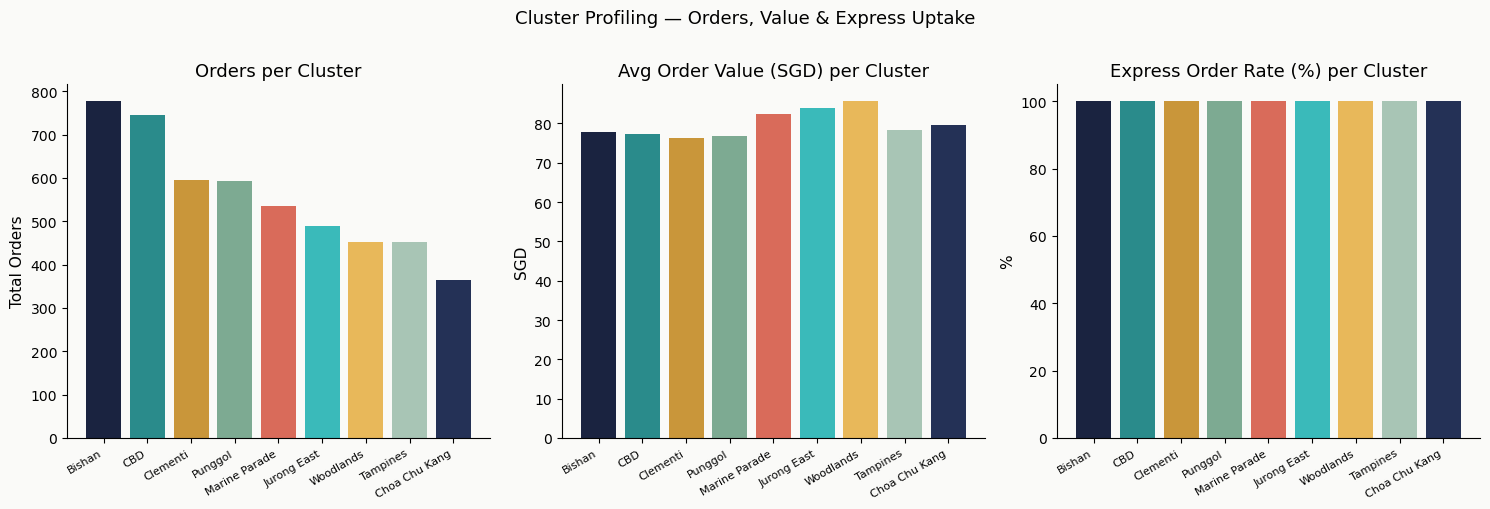

,cluster_label,total_orders,total_revenue,avg_order_value,avg_effort,express_orders,express_rate_pct,revenue_per_order
0,Bishan / Toa Payoh,777,60454.87,77.805495,2.006435,777,100.0,77.81
1,CBD / Tanjong Pagar,744,57596.55,77.414718,1.998656,744,100.0,77.41
3,Clementi / West Coast,595,45308.92,76.149445,1.978151,595,100.0,76.15
6,Punggol / Sengkang,592,45437.76,76.752973,1.957770,592,100.0,76.75
5,Marine Parade / Katong,535,44078.67,82.390037,1.876636,535,100.0,82.39
4,Jurong East / West,489,40969.39,83.781984,2.055215,489,100.0,83.78
8,Woodlands / Marsiling,452,38708.12,85.637434,2.053097,452,100.0,85.64
7,Tampines / Pasir Ris,451,35356.64,78.396098,1.977827,451,100.0,78.40
2,Choa Chu Kang / Bukit Panjang,365,29077.15,79.663425,1.931507,365,100.0,79.66


In [15]:
cluster_profile = (
    df_clean.groupby('cluster_label')
    .agg(
        total_orders    = ('order_id',       'count'),
        total_revenue   = ('order_value_sgd','sum'),
        avg_order_value = ('order_value_sgd','mean'),
        avg_effort      = ('effort_score',   'mean'),
        express_orders  = ('express_type',   lambda x: (x != 'None').sum()),
    )
    .reset_index()
    .sort_values('total_orders', ascending=False)
)
cluster_profile['express_rate_pct']   = (cluster_profile.express_orders / cluster_profile.total_orders * 100).round(1)
cluster_profile['revenue_per_order']  = cluster_profile.avg_order_value.round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Orders
axes[0].bar(range(len(cluster_profile)), cluster_profile['total_orders'],
            color=PALETTE[:len(cluster_profile)])
axes[0].set_xticks(range(len(cluster_profile)))
axes[0].set_xticklabels([z.split('/')[0].strip() for z in cluster_profile['cluster_label']], rotation=30, ha='right', fontsize=8)
axes[0].set_title('Orders per Cluster')
axes[0].set_ylabel('Total Orders')

# Avg order value
axes[1].bar(range(len(cluster_profile)), cluster_profile['avg_order_value'],
            color=PALETTE[:len(cluster_profile)])
axes[1].set_xticks(range(len(cluster_profile)))
axes[1].set_xticklabels([z.split('/')[0].strip() for z in cluster_profile['cluster_label']], rotation=30, ha='right', fontsize=8)
axes[1].set_title('Avg Order Value (SGD) per Cluster')
axes[1].set_ylabel('SGD')

# Express rate
axes[2].bar(range(len(cluster_profile)), cluster_profile['express_rate_pct'],
            color=PALETTE[:len(cluster_profile)])
axes[2].set_xticks(range(len(cluster_profile)))
axes[2].set_xticklabels([z.split('/')[0].strip() for z in cluster_profile['cluster_label']], rotation=30, ha='right', fontsize=8)
axes[2].set_title('Express Order Rate (%) per Cluster')
axes[2].set_ylabel('%')

plt.suptitle('Cluster Profiling — Orders, Value & Express Uptake', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('cluster_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

cluster_profile

---
## 7. Delivery Slot Demand by Zone
### Which zones prefer which delivery slots?

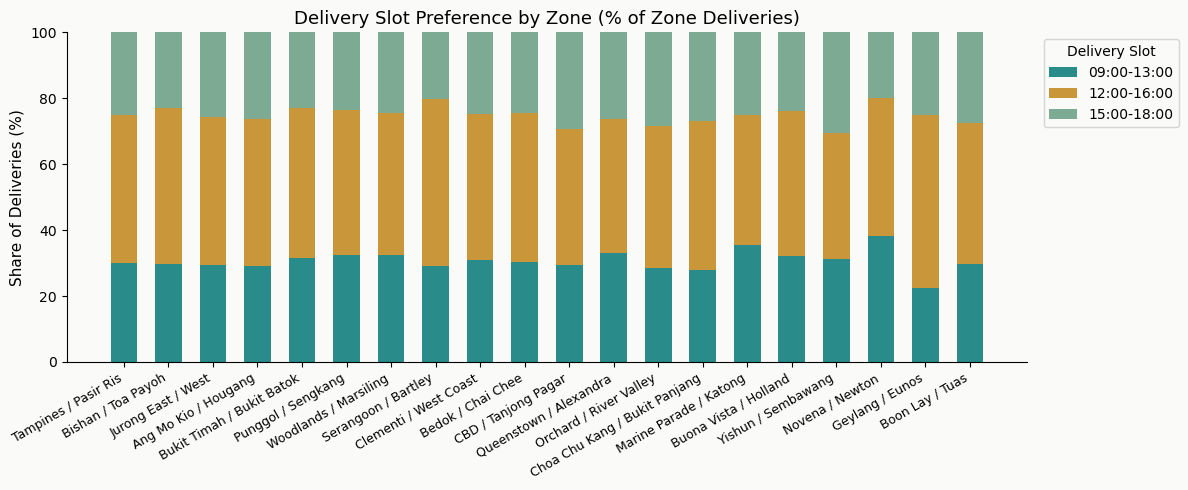

In [16]:
slot_zone = (
    df.groupby(['zone','delivery_slot'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id':'orders'})
    .pivot(index='zone', columns='delivery_slot', values='orders')
    .fillna(0)
    .astype(int)
)
# Sort by total
slot_zone = slot_zone.loc[zone_summary['zone']]

# Normalise to % within each zone
slot_zone_pct = slot_zone.div(slot_zone.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 5))
slot_colors = [PALETTE[1], PALETTE[2], PALETTE[3]]
bottom = np.zeros(len(slot_zone_pct))

for col, color in zip(slot_zone_pct.columns, slot_colors):
    ax.bar(slot_zone_pct.index, slot_zone_pct[col], bottom=bottom,
           color=color, label=col, width=0.6)
    bottom += slot_zone_pct[col].values

ax.set_ylabel('Share of Deliveries (%)')
ax.set_title('Delivery Slot Preference by Zone (% of Zone Deliveries)', fontsize=13)
ax.legend(title='Delivery Slot', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig('slot_preference_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Insight Summary & Recommendations

In [17]:
top3 = zone_summary.head(3)
top_zone = zone_summary.iloc[0]
cbd_zone = zone_summary[zone_summary.zone.str.contains('CBD')].iloc[0]
total_drivers = driver_df['drivers_needed_daily'].sum()

print('=' * 65)
print('  ROUTE OPTIMISATION — KEY INSIGHTS & RECOMMENDATIONS')
print('=' * 65)

print(f"""
🗺️  INSIGHT 1 — HIGH-DENSITY ZONES
   Top 3 zones account for {top3.total_orders.sum()/zone_summary.total_orders.sum()*100:.0f}% of all orders:
   1. {top3.iloc[0].zone:<28} ({top3.iloc[0].total_orders:,} orders, {top3.iloc[0].revenue_share_pct}% revenue)
   2. {top3.iloc[1].zone:<28} ({top3.iloc[1].total_orders:,} orders, {top3.iloc[1].revenue_share_pct}% revenue)
   3. {top3.iloc[2].zone:<28} ({top3.iloc[2].total_orders:,} orders, {top3.iloc[2].revenue_share_pct}% revenue)
   → Prioritise dedicated loop routes for these zones Mon–Fri.

🚗  INSIGHT 2 — DRIVER REQUIREMENT
   Total drivers needed across all zones (daily): {total_drivers}
   Peak slot (12:00–16:00) requires {driver_df.drivers_peak_slot.sum()} drivers fleet-wide.
   → Allocate {driver_df.sort_values('drivers_needed_daily',ascending=False).iloc[0].drivers_needed_daily} drivers to {driver_df.sort_values('drivers_needed_daily',ascending=False).iloc[0].zone} alone.

💰  INSIGHT 3 — HIGH-VALUE LOW-VOLUME ZONE
   {cbd_zone.zone} has only {cbd_zone.total_orders:,} orders but avg order value ${cbd_zone.avg_order_value:.2f}.
   → Bundle CBD stops with adjacent zones; upsell express services.

📦  INSIGHT 4 — CLUSTER-BASED ROUTING
   K-Means identified {OPTIMAL_K} natural delivery clusters matching SG postal zones.
   → Assign 1 dedicated driver per cluster for the morning and evening slots.
   → Double up on the peak 12:00–16:00 slot for high-density clusters.

✅  RECOMMENDED ACTIONS:
   • Implement zone-based delivery planning (not order-by-order)
   • Use cluster centroids as driver staging/rest points
   • Pre-sort collection bags by cluster before dispatch
   • Review Fri demand spike — consider +1 driver on Fridays for top 3 zones
""")
print('=' * 65)

  ROUTE OPTIMISATION — KEY INSIGHTS & RECOMMENDATIONS

🗺️  INSIGHT 1 — HIGH-DENSITY ZONES
   Top 3 zones account for 21% of all orders:
   1. Tampines / Pasir Ris         (381 orders, 7.9% revenue)
   2. Bishan / Toa Payoh           (342 orders, 6.5% revenue)
   3. Jurong East / West           (338 orders, 7.5% revenue)
   → Prioritise dedicated loop routes for these zones Mon–Fri.

🚗  INSIGHT 2 — DRIVER REQUIREMENT
   Total drivers needed across all zones (daily): 20
   Peak slot (12:00–16:00) requires 20 drivers fleet-wide.
   → Allocate 1 drivers to Tampines / Pasir Ris alone.

💰  INSIGHT 3 — HIGH-VALUE LOW-VOLUME ZONE
   CBD / Tanjong Pagar has only 248 orders but avg order value $78.11.
   → Bundle CBD stops with adjacent zones; upsell express services.

📦  INSIGHT 4 — CLUSTER-BASED ROUTING
   K-Means identified 9 natural delivery clusters matching SG postal zones.
   → Assign 1 dedicated driver per cluster for the morning and evening slots.
   → Double up on the peak 12:00–16:00 

In [18]:
# ══════════════════════════════════════════════════════════════════════════════
#  ASTORIA — Dashboard Data Export Cell
#  Paste this as a NEW CELL at the bottom of your notebook and run it.
#  It reads variables already in memory and writes astoria_data.json.
# ══════════════════════════════════════════════════════════════════════════════

import json
import numpy as np
import pandas as pd

# ── Safe type converter (numpy → plain Python) ────────────────────────────────
def _safe(v):
    if isinstance(v, (np.integer,)):   return int(v)
    if isinstance(v, (np.floating,)):  return round(float(v), 4)
    if isinstance(v, float):           return round(v, 4)
    if isinstance(v, np.ndarray):      return v.tolist()
    if isinstance(v, pd.Timestamp):    return str(v.date())
    if pd.isna(v):                     return None
    return v

# ── 1. ZONE SUMMARY ───────────────────────────────────────────────────────────
_zone_cols_wanted = [
    'zone', 'total_orders', 'total_revenue', 'avg_order_value',
    'density_tier', 'recommended_drivers', 'revenue_share_pct',
    'lat_center', 'lng_center',
]
_zone_cols = [c for c in _zone_cols_wanted if c in zone_summary.columns]
print(f"zone_summary columns available: {list(zone_summary.columns)}")
print(f"Exporting zone columns: {_zone_cols}")

zones_out = [
    {c: _safe(row[c]) for c in _zone_cols}
    for _, row in zone_summary.iterrows()
]

# ── 2. DRIVER ALLOCATION ──────────────────────────────────────────────────────
_driver_cols_wanted = [
    'zone', 'density_tier', 'total_orders', 'orders_per_day',
    'drivers_needed_daily', 'drivers_morning_slot',
    'drivers_peak_slot', 'drivers_evening_slot',
]
_driver_cols = [c for c in _driver_cols_wanted if c in driver_df.columns]
print(f"driver_df columns available: {list(driver_df.columns)}")
print(f"Exporting driver columns: {_driver_cols}")

drivers_out = [
    {c: _safe(row[c]) for c in _driver_cols}
    for _, row in driver_df.iterrows()
]

# ── 3. DELIVERY SLOT % BY ZONE (top 10 zones) ─────────────────────────────────
_top10 = zone_summary['zone'].head(10).tolist()

_slot_raw = (
    df.groupby(['zone', 'delivery_slot'])['order_id']
    .count()
    .reset_index()
    .rename(columns={'order_id': 'n'})
    .pivot(index='zone', columns='delivery_slot', values='n')
    .fillna(0).astype(int)
)
_slot_pct = _slot_raw.div(_slot_raw.sum(axis=1), axis=0) * 100
_slot_pct = _slot_pct.reindex([z for z in _top10 if z in _slot_pct.index])

_slot_cols = _slot_pct.columns.tolist()
slot_out = {'zones': [z.split(' / ')[0] for z in _slot_pct.index.tolist()]}
for col in _slot_cols:
    slot_out[col] = [round(float(v), 1) for v in _slot_pct[col]]

# ── 4. DAY-OF-WEEK DEMAND ─────────────────────────────────────────────────────
_day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
_dow = (
    df.groupby('booking_day_of_week')['order_id']
    .count()
    .reindex([d for d in _day_order if d in df['booking_day_of_week'].unique()])
    .fillna(0).astype(int)
)
dow_out = {
    'days':   _dow.index.tolist(),
    'orders': _dow.values.tolist(),
}

# ── 5. KMEANS CLUSTER SUMMARY ─────────────────────────────────────────────────
_cluster_col = next(
    (c for c in ['kmeans_cluster', 'cluster', 'Cluster', 'cluster_label']
     if c in df.columns),
    None
)
if _cluster_col:
    _cdf = (
        df.groupby(_cluster_col)
        .agg(orders=('order_id','count'),
             revenue=('order_value_sgd','sum'),
             lat=('latitude','mean'),
             lng=('longitude','mean'))
        .reset_index()
        .rename(columns={_cluster_col: 'cluster_id'})
    )
    clusters_out = [
        {'cluster_id': _safe(r['cluster_id']),
         'orders':     _safe(r['orders']),
         'revenue':    _safe(r['revenue']),
         'lat':        _safe(r['lat']),
         'lng':        _safe(r['lng'])}
        for _, r in _cdf.iterrows()
    ]
    print(f"Cluster column used: '{_cluster_col}' → {len(clusters_out)} clusters")
else:
    clusters_out = []
    print("⚠️  No cluster column found in df — clusters_out will be empty")

# ── 6. EXPRESS UPTAKE BY ZONE ─────────────────────────────────────────────────
_express = (
    df.groupby('zone')['express_type']
    .apply(lambda s: round((s.notna().sum() / len(s)) * 100, 1))
    .reset_index()
    .rename(columns={'express_type': 'express_pct'})
)
express_map = {row['zone']: _safe(row['express_pct']) for _, row in _express.iterrows()}

# ── 7. MONTHLY REVENUE TREND ──────────────────────────────────────────────────
_monthly = (
    df.assign(month=df['booking_date'].dt.to_period('M'))
    .groupby('month')
    .agg(revenue=('order_value_sgd','sum'), orders=('order_id','count'))
    .reset_index()
)
monthly_out = {
    'months':  [str(m) for m in _monthly['month']],
    'revenue': [round(float(v), 2) for v in _monthly['revenue']],
    'orders':  [int(v) for v in _monthly['orders']],
}

# ── 8. TOP-LEVEL KPIs ─────────────────────────────────────────────────────────
_top_zone = zone_summary.iloc[0]
kpis_out = {
    'total_orders':        int(len(df)),
    'total_revenue':       round(float(df['order_value_sgd'].sum()), 2),
    'avg_order_value':     round(float(df['order_value_sgd'].mean()), 2),
    'total_zones':         int(df['zone'].nunique()),
    'optimal_k_clusters':  int(OPTIMAL_K) if 'OPTIMAL_K' in dir() else len(clusters_out),
    'total_drivers_daily': int(driver_df['drivers_needed_daily'].sum()) if 'drivers_needed_daily' in driver_df.columns else None,
    'date_min':            str(df['booking_date'].min().date()),
    'date_max':            str(df['booking_date'].max().date()),
    'top_zone':            str(_top_zone['zone']),
    'top_zone_orders':     int(_top_zone['total_orders']),
    'top_zone_rev_share':  float(_top_zone['revenue_share_pct']),
}

# ── 9. ASSEMBLE & WRITE ───────────────────────────────────────────────────────
output = {
    'kpis':          kpis_out,
    'zones':         zones_out,
    'drivers':       drivers_out,
    'slot_data':     slot_out,
    'slot_columns':  _slot_cols,
    'day_of_week':   dow_out,
    'clusters':      clusters_out,
    'express_map':   express_map,
    'monthly_trend': monthly_out,
}

_path = 'astoria_data.json'
with open(_path, 'w') as f:
    json.dump(output, f, indent=2, default=str)

print(f"\n✅  Export complete → {_path}")
print(f"   {len(zones_out)} zones · {len(clusters_out)} clusters · {len(monthly_out['months'])} months of data")
print(f"   KPIs: {kpis_out['total_orders']:,} orders · ${kpis_out['total_revenue']:,.0f} total revenue")

zone_summary columns available: ['zone', 'total_orders', 'total_items', 'total_revenue', 'avg_order_value', 'avg_effort', 'lat_center', 'lng_center', 'density_tier', 'orders_per_week', 'recommended_drivers', 'revenue_share_pct']
Exporting zone columns: ['zone', 'total_orders', 'total_revenue', 'avg_order_value', 'density_tier', 'recommended_drivers', 'revenue_share_pct', 'lat_center', 'lng_center']
driver_df columns available: ['zone', 'total_orders', 'total_items', 'total_revenue', 'avg_order_value', 'avg_effort', 'lat_center', 'lng_center', 'density_tier', 'orders_per_week', 'recommended_drivers', 'revenue_share_pct', 'orders_per_day', 'drivers_needed_daily', 'drivers_peak_slot', 'drivers_morning_slot', 'drivers_evening_slot']
Exporting driver columns: ['zone', 'density_tier', 'total_orders', 'orders_per_day', 'drivers_needed_daily', 'drivers_morning_slot', 'drivers_peak_slot', 'drivers_evening_slot']
⚠️  No cluster column found in df — clusters_out will be empty

✅  Export complete 